# Workshop - Recunoașterea cifrelor scrise de mână cu Multinomial Naive Bayes

În acest workshop vom construi un model care primește imaginea unei cifre scrise de mână și încearcă să prezică cifra reprezentată.

Vom folosi varianta **EMNIST-MNIST**, care conține cifrele:

`0, 1, 2, 3, 4, 5, 6, 7, 8, 9`


## 1. Setup și importuri

Vom folosi:

- `NumPy` pentru array-uri;
- `Matplotlib` pentru afișarea imaginilor;
- `torchvision` doar pentru descărcarea dataset-ului;
- `scikit-learn` pentru model și evaluare.

În Google Colab, aceste biblioteci sunt de obicei deja disponibile.

In [1]:
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import torch
import torchvision

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from torchvision.datasets import EMNIST

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("PyTorch:", torch.__version__)
print("torchvision:", torchvision.__version__)

Python: 3.12.3
NumPy: 2.5.1
Matplotlib: 3.11.1
scikit-learn: 1.9.0
PyTorch: 2.13.0+cu130
torchvision: 0.28.0+cu130


## 2. Descărcarea dataset-ului

Folosim `torchvision.datasets.EMNIST`.

Parametrul:

`split="mnist"`

selectează varianta EMNIST care conține doar cifrele `0-9`.

Dataset-ul vine deja separat în:

- train set - folosit pentru antrenare;
- test set - folosit pentru evaluare.

`download=True` descarcă automat fișierele la prima rulare.

La rulările următoare, fișierele deja descărcate sunt refolosite.

In [2]:
train_dataset = EMNIST(
    root="./data",
    split="mnist",
    train=True,
    download=True,
)

test_dataset = EMNIST(
    root="./data",
    split="mnist",
    train=False,
    download=True,
)

print("Număr imagini train:", len(train_dataset))
print("Număr imagini test:", len(test_dataset))

100.0%


Număr imagini train: 60000
Număr imagini test: 10000


## 3. Ce conține dataset-ul

Fiecare observație are două componente:

- imaginea;
- label-ul corect.

O imagine are dimensiunea:

$$
28 \times 28
$$

Prin urmare, conține:

$$
28 \cdot 28 = 784
$$

pixeli.

Fiecare pixel are o intensitate între:

- `0` - pixel întunecat;
- `255` - pixel luminos.

Dataset-ul este unul de imagini.

Pentru model, fiecare imagine va fi transformată temporar într-un vector cu 784 de intensități.

$$
imagine\ 28 \times 28
\rightarrow
vector\ cu\ 784\ pixeli
$$

Această transformare nu schimbă natura datelor. Observația rămâne o imagine; doar reprezentarea numerică este adaptată la forma cerută de model.

In [3]:
X_train_images = train_dataset.data.numpy()
y_train_all = train_dataset.targets.numpy()

X_test_images = test_dataset.data.numpy()
y_test_all = test_dataset.targets.numpy()

print("Forma imaginilor train:", X_train_images.shape)
print("Forma label-urilor train:", y_train_all.shape)

print("Forma imaginilor test:", X_test_images.shape)
print("Forma label-urilor test:", y_test_all.shape)

print("\nValoarea minimă a unui pixel:", X_train_images.min())
print("Valoarea maximă a unui pixel:", X_train_images.max())

Forma imaginilor train: (60000, 28, 28)
Forma label-urilor train: (60000,)
Forma imaginilor test: (10000, 28, 28)
Forma label-urilor test: (10000,)

Valoarea minimă a unui pixel: 0
Valoarea maximă a unui pixel: 255


## 4. Afișarea unei imagini

`torchvision` ne oferă fiecare imagine ca o matrice `28 × 28`.

Pentru afișare folosim `plt.imshow()`.

Imaginile EMNIST pot apărea rotite față de orientarea obișnuită.

Pentru afișare aplicăm transpunerea:

`.T`

Transpunerea schimbă rândurile în coloane și corectează orientarea imaginii pentru vizualizare.

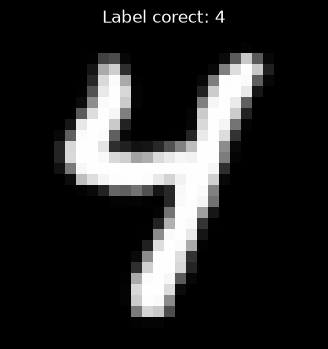

In [4]:
sample_index = 0

sample_image = X_train_images[sample_index]
sample_label = y_train_all[sample_index]

plt.figure(figsize=(4, 4))
plt.imshow(
    sample_image.T,
    cmap="gray",
)
plt.title(
    f"Label corect: {sample_label}"
)
plt.axis("off")
plt.show()

## Task 1 - Afișarea unei imagini

Alege o altă observație din train set și afișeaz-o.

### Cerințe

1. Alege un index, de exemplu `25`.
2. Extrage imaginea din `X_train_images`.
3. Extrage label-ul corespunzător din `y_train_all`.
4. Afișează imaginea folosind `.T` și `cmap="gray"`.
5. Afișează label-ul în titlu.

In [ ]:
chosen_index = ...

chosen_image = ...
chosen_label = ...

plt.figure(figsize=(4, 4))
plt.imshow(
    ...,
    cmap="gray",
)
plt.title(...)
plt.axis("off")
plt.show()

<details>
<summary><strong>Hint</strong></summary>

Imaginea și label-ul folosesc același index:

<pre><code>chosen_image = X_train_images[chosen_index]
chosen_label = y_train_all[chosen_index]</code></pre>

Pentru afișare:

<pre><code>plt.imshow(
    chosen_image.T,
    cmap="gray",
)</code></pre>

</details>

<details>
<summary><strong>Soluție</strong></summary>

<pre><code>chosen_index = 25

chosen_image = X_train_images[
    chosen_index
]

chosen_label = y_train_all[
    chosen_index
]

plt.figure(figsize=(4, 4))

plt.imshow(
    chosen_image.T,
    cmap="gray",
)

plt.title(
    f"Label corect: {chosen_label}"
)

plt.axis("off")
plt.show()</code></pre>

</details>

## 5. Vizualizarea mai multor exemple

O singură imagine nu ne spune suficient despre dataset.

Este util să vedem mai multe cifre pentru a observa:

- stiluri diferite de scriere;
- cifre clare;
- cifre ambigue;
- variații între observații.

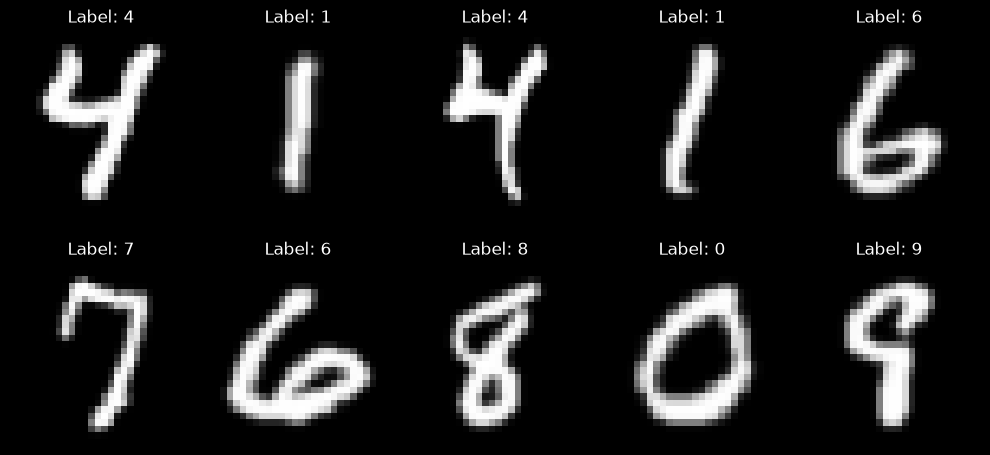

In [5]:
figure, axes = plt.subplots(
    2,
    5,
    figsize=(10, 5),
)

for index, axis in enumerate(axes.ravel()):
    axis.imshow(
        X_train_images[index].T,
        cmap="gray",
    )

    axis.set_title(
        f"Label: {y_train_all[index]}"
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

## 6. Folosirea unui subset pentru workshop

Dataset-ul complet este util, dar pentru workshop vrem ca toate celulele să ruleze rapid.

Vom folosi implicit:

- `15.000` imagini pentru train;
- `3.000` imagini pentru test.

Selectarea este stratificată.

Asta înseamnă că păstrăm aproximativ aceeași proporție pentru fiecare cifră.

`random_state=42` face selecția reproductibilă.

In [6]:
train_indices, _ = train_test_split(
    np.arange(len(X_train_images)),
    train_size=15_000,
    random_state=42,
    stratify=y_train_all,
)

test_indices, _ = train_test_split(
    np.arange(len(X_test_images)),
    train_size=3_000,
    random_state=42,
    stratify=y_test_all,
)

X_train_subset = X_train_images[
    train_indices
]

y_train = y_train_all[
    train_indices
]

X_test_subset = X_test_images[
    test_indices
]

y_test = y_test_all[
    test_indices
]

print("Train subset:", X_train_subset.shape)
print("Test subset:", X_test_subset.shape)

labels, counts = np.unique(
    y_train,
    return_counts=True,
)

print("\nDistribuția claselor în train:")
for label, count in zip(labels, counts):
    print(f"Cifra {label}: {count} imagini")

Train subset: (15000, 28, 28)
Test subset: (3000, 28, 28)

Distribuția claselor în train:
Cifra 0: 1500 imagini
Cifra 1: 1500 imagini
Cifra 2: 1500 imagini
Cifra 3: 1500 imagini
Cifra 4: 1500 imagini
Cifra 5: 1500 imagini
Cifra 6: 1500 imagini
Cifra 7: 1500 imagini
Cifra 8: 1500 imagini
Cifra 9: 1500 imagini


## 7. Cum pregătim imaginile pentru model

Fiecare observație este încă o imagine `28 × 28`.

`MultinomialNB` primește un array bidimensional cu forma:

$$
(număr\ de\ observații,\ număr\ de\ features)
$$

De aceea, transformăm fiecare imagine într-un vector cu 784 de valori.

De exemplu:

$$
\begin{bmatrix}
p_1 & p_2 \\
p_3 & p_4
\end{bmatrix}
\rightarrow
[p_1,\ p_2,\ p_3,\ p_4]
$$

Operația se numește **flattening** sau aplatizare.

Nu amestecăm imaginile între ele.

Fiecare rând rezultat reprezintă în continuare o singură imagine.

In [10]:
X_train = X_train_subset.reshape(
    len(X_train_subset),
    28 * 28,
)

X_test = X_test_subset.reshape(
    len(X_test_subset),
    28 * 28,
)

print("Forma inițială train:", X_train_subset.shape)
print("Forma pentru model:", X_train.shape)

print("\nFiecare imagine are:")
print(X_train.shape[1], "features")

Forma inițială train: (15000, 28, 28)
Forma pentru model: (15000, 784)

Fiecare imagine are:
784 features


## 7.1. Normalizarea intensităților pixelilor

Pixelii imaginilor EMNIST au valori între `0` și `255`.

De exemplu:

- `0` înseamnă că pixelul este complet întunecat;
- `128` reprezintă o intensitate intermediară;
- `235` reprezintă un pixel foarte luminos;
- `255` reprezintă intensitatea maximă.

Putem transforma aceste valori în intervalul `0–1` prin împărțirea fiecărui pixel la `255`.

Formula este:

$$
pixel_{normalizat} =
\frac{pixel_{original}}{255}
$$

De exemplu:

$$
\frac{0}{255} = 0
$$

$$
\frac{128}{255} \approx 0.50
$$

$$
\frac{235}{255} \approx 0.92
$$

$$
\frac{255}{255} = 1
$$

După normalizare:

- `0` rămâne intensitatea minimă;
- `1` reprezintă intensitatea maximă;
- valorile intermediare își păstrează proporția.

Normalizarea nu schimbă forma cifrei.

Ea schimbă doar scara numerică folosită pentru reprezentarea pixelilor.

De exemplu, vectorul:

$$
[0,\ 128,\ 235,\ 255]
$$

devine aproximativ:

$$
[0,\ 0.50,\ 0.92,\ 1]
$$

`MultinomialNB` acceptă aceste valori deoarece ele rămân nenegative.

Este important să aplicăm aceeași transformare atât datelor de train, cât și datelor de test.

In [12]:
X_train_normalized = (
    X_train.astype("float32") / 255.0
)

X_test_normalized = (
    X_test.astype("float32") / 255.0
)

print(
    "Valoarea minimă după normalizare:",
    X_train_normalized.min(),
)

print(
    "Valoarea maximă după normalizare:",
    X_train_normalized.max(),
)

print(
    "Exemplu: pixelul 235 normalizat:",
    235 / 255,
)

Valoarea minimă după normalizare: 0.0
Valoarea maximă după normalizare: 1.0
Exemplu: pixelul 235 normalizat: 0.9215686274509803


## 8. De ce folosim Multinomial Naive Bayes

Înainte de antrenare, fiecare imagine are forma:

$$
28 \times 28
$$

Pentru model, imaginea este aplatizată într-un vector cu `784` de valori:

$$
[pixel_1,\ pixel_2,\ \ldots,\ pixel_{784}]
$$

Fiecare valoare reprezintă intensitatea unui pixel.

În EMNIST, intensitățile sunt numere nenegative:

$$
0 \leq pixel \leq 255
$$

De exemplu, o parte foarte mică dintr-o imagine ar putea fi reprezentată astfel:

$$
[0,\ 0,\ 35,\ 180,\ 255,\ 70,\ 0]
$$

Interpretarea este:

- `0` - pixelul nu contribuie vizibil la forma cifrei;
- o valoare mică, precum `35` - pixel slab activ;
- o valoare mare, precum `255` - pixel puternic activ.

`MultinomialNB` poate lucra cu astfel de valori deoarece toate sunt nenegative.

### Ce încearcă să învețe modelul

Pentru fiecare cifră, modelul analizează toate imaginile de train care au acel label.

De exemplu, pentru cifra `1`, modelul vede multe imagini diferite ale cifrei `1`.

În aceste imagini, anumite poziții ale pixelilor tind să aibă intensități mari mai des decât altele.

Simplificat, modelul poate învăța că:

- pentru cifra `1`, pixelii din zona centrală sunt frecvent activi;
- pentru cifra `0`, pixelii de pe contur sunt frecvent activi;
- pentru cifra `7`, pixelii din partea de sus și de pe diagonală sunt frecvent activi.

Modelul nu memorează o singură imagine pentru fiecare cifră.

El învață un tipar numeric pentru fiecare clasă.

### Exemplu basic

Presupunem că imaginile ar avea doar 4 pixeli.

Pentru cifra `1`, modelul ar putea observa frecvent valori de forma:

$$
[0,\ 220,\ 0,\ 210]
$$

Pentru cifra `0`, ar putea observa mai des:

$$
[180,\ 0,\ 170,\ 0]
$$

Ideea este că fiecare cifră produce un tipar diferit de intensități.

Pentru o imagine nouă:

$$
[10,\ 200,\ 5,\ 190]
$$

modelul observă că intensitățile mari apar în poziții asemănătoare cu tiparul cifrei `1`.

Prin urmare, cifra `1` va primi un scor mai mare decât cifra `0`.

### Ce calculează modelul pentru o imagine nouă

Pentru fiecare clasă posibilă:

$$
0,\ 1,\ 2,\ \ldots,\ 9
$$

modelul combină două tipuri de informații:

1. cât de frecventă este clasa în datele de train;
2. cât de bine se potrivesc intensitățile pixelilor imaginii cu tiparul învățat pentru acea clasă.

Conceptual, modelul compară:

$$
P(clasă \mid pixeli)
$$

Aceasta se citește:

> probabilitatea clasei, cunoscând valorile pixelilor.

Modelul calculează câte un scor pentru fiecare cifră:

- scor pentru `0`;
- scor pentru `1`;
- scor pentru `2`;
- ...
- scor pentru `9`.

Predicția este clasa cu scorul cel mai mare.

De exemplu:

| Cifră | Scor calculat |
|---:|---:|
| 0 | 0.03 |
| 1 | 0.07 |
| 2 | 0.04 |
| 3 | 0.08 |
| 4 | 0.05 |
| 5 | 0.06 |
| 6 | 0.02 |
| 7 | 0.58 |
| 8 | 0.04 |
| 9 | 0.03 |

În acest exemplu, modelul prezice:

`7`

deoarece cifra `7` are scorul cel mai mare.

Valorile reale folosite intern sunt calculate într-o formă numerică mai stabilă, dar interpretarea rămâne aceeași: modelul compară cât de bine se potrivește imaginea cu fiecare clasă.

### De ce se numește „Naive”

Partea „Naive” vine dintr-o presupunere simplificatoare.

Modelul tratează contribuția fiecărui pixel separat, cunoscând clasa.

Cu alte cuvinte, analizează contribuția lui:

- `pixel_1`;
- `pixel_2`;
- ...
- `pixel_784`;

ca și cum fiecare pixel ar aduce informație separat.

În realitate, pixelii nu sunt independenți.

De exemplu:

- o linie verticală este formată din mai mulți pixeli vecini;
- un cerc este format din pixeli conectați;
- poziția unui pixel are legătură cu pixelii din jurul său.

Modelul nu înțelege direct concepte precum:

- linie;
- curbă;
- contur;
- formă;
- relație spațială.

El vede doar 784 de valori numerice și contribuția individuală a fiecăreia.

### De ce îl folosim totuși

Chiar dacă presupunerea este simplificatoare, `MultinomialNB` este util deoarece:

- este rapid;
- se antrenează ușor;
- funcționează cu features nenegative;
- oferă un baseline clar;
- ne permite să construim primul pipeline complet de clasificare a imaginilor.

Un baseline este un model simplu folosit ca punct de referință.

Mai târziu, rezultatele altor modele pot fi comparate cu rezultatul obținut de acest baseline.

Important:

> Nu folosim `MultinomialNB` deoarece este cel mai performant model posibil pentru imagini, ci deoarece este suficient de simplu pentru a înțelege întregul proces de antrenare, predicție și evaluare.

## 9. Parametrul `alpha`

Vom crea modelul astfel:

`MultinomialNB(alpha=1.0)`

Parametrul `alpha` controlează **smoothing-ul**.

Smoothing-ul este o corecție aplicată probabilităților învățate de model, astfel încât o valoare care nu a fost observată în train să nu primească automat probabilitatea zero.

### De ce este problematică probabilitatea zero

Să presupunem că, pentru cifra `7`, un anumit pixel nu a avut deloc intensitate în imaginile de train.

Fără smoothing, modelul poate ajunge să considere că:

$$
P(pixel \mid cifra\ 7) = 0
$$

Aceasta se citește:

> probabilitatea ca acel pixel să apară, dacă imaginea reprezintă cifra `7`, este zero.

Naive Bayes combină contribuțiile mai multor features prin înmulțirea probabilităților.

Simplificat, pentru o clasă putem avea:

$$
P(clasă \mid pixeli)
\propto
P(clasă)
\cdot
P(pixel_1 \mid clasă)
\cdot
P(pixel_2 \mid clasă)
\cdot
\dots
$$

Dacă una dintre probabilități este zero:

$$
0.7 \cdot 0.8 \cdot 0 \cdot 0.9 = 0
$$

întregul rezultat devine zero.

Asta înseamnă că un singur pixel ar putea elimina complet o clasă, chiar dacă restul imaginii seamănă foarte bine cu acea cifră.

### Exemplu simplificat

Presupunem că vrem să calculăm un scor pentru cifra `7`.

Modelul combină contribuțiile a trei pixeli:

$$
0.8 \cdot 0.6 \cdot 0
$$

Rezultatul este:

$$
0
$$

Chiar dacă primii doi pixeli se potrivesc bine cu cifra `7`, al treilea pixel anulează complet scorul.

Această concluzie este prea dură.

Faptul că modelul nu a observat o anumită situație în train nu înseamnă neapărat că situația este imposibilă.

### Ce face smoothing-ul

Smoothing-ul adaugă o cantitate mică înainte de calcularea probabilităților.

În loc ca un pixel neobservat să aibă valoarea:

$$
0
$$

poate primi o valoare mică, diferită de zero.

De exemplu:

$$
0.8 \cdot 0.6 \cdot 0.01
=
0.0048
$$

Scorul este mic, dar clasa nu este eliminată complet.

Modelul poate continua să compare această clasă cu celelalte clase.

### Ce înseamnă `alpha=1.0`

Când scriem:

`MultinomialNB(alpha=1.0)`

aplicăm o formă de smoothing numită frecvent **Laplace smoothing**.

Intuitiv, modelul se comportă ca și cum ar adăuga o cantitate mică de observație pentru fiecare feature și fiecare clasă.

Astfel:

- valorile zero sunt evitate;
- modelul nu devine excesiv de sigur;
- clasele nu sunt eliminate din cauza unei singure poziții de pixel;
- predicțiile sunt mai stabile pe imagini noi.

### Cum influențează valoarea lui `alpha`

O valoare foarte mică:

`alpha = 0.001`

înseamnă puțin smoothing.

Modelul se bazează foarte mult pe valorile observate în train.

O valoare mai mare:

`alpha = 10`

înseamnă mai mult smoothing.

Diferențele dintre features sunt „netezite” mai puternic, iar modelul devine mai prudent.

Pentru workshop păstrăm:

`alpha=1.0`

Este o valoare simplă și potrivită pentru un baseline.

Nu încercăm încă să găsim cel mai bun `alpha`.


## Task 2 - Antrenarea modelului

### Cerințe

1. Creează un model `MultinomialNB` cu `alpha=1.0`.
2. Antrenează modelul pe `X_train_normalized` și `y_train`.
3. Prezice cifrele pentru `X_test_normalized`.
4. Calculează accuracy.
5. Afișează rezultatul și în procente.

Accuracy reprezintă proporția imaginilor clasificate corect.

De exemplu:

`accuracy = 0.80`

înseamnă că aproximativ `80%` dintre imaginile de test au fost clasificate corect.

In [ ]:
model = ...

model.fit(
    ...,
    ...,
)

predictions = ...

accuracy = ...

print("Accuracy:", accuracy)
print(
    "Accuracy în procente:",
    accuracy * 100,
)

<details>
<summary><strong>Hint</strong></summary>

Construiește modelul:

<pre><code>model = MultinomialNB(
    alpha=1.0
)</code></pre>

Antrenează modelul:

<pre><code>model.fit(
    X_train_normalized,
    y_train,
)</code></pre>

Prezice:

<pre><code>predictions = model.predict(
    X_test_normalized
)</code></pre>

Calculează accuracy:

<pre><code>accuracy_score(
    y_test,
    predictions,
)</code></pre>

</details>

<details>
<summary><strong>Soluție</strong></summary>

<pre><code>model = MultinomialNB(
    alpha=1.0
)

model.fit(
    X_train_normalized,
    y_train,
)

predictions = model.predict(
    X_test_normalized
)

accuracy = accuracy_score(
    y_test,
    predictions,
)

print("Accuracy:", accuracy)

print(
    "Accuracy în procente:",
    accuracy * 100,
)</code></pre>

</details>

## 10. Interpretarea accuracy

Accuracy ne spune ce proporție din toate imaginile de test a fost clasificată corect.

Formula este:

$$
accuracy =
\frac{număr\ de\ predicții\ corecte}
{număr\ total\ de\ predicții}
$$

Accuracy este utilă deoarece oferă un rezumat rapid.

Totuși, nu ne spune:

- ce cifre sunt recunoscute bine;
- ce cifre sunt confundate;
- cum arată imaginile greșite.

Pentru aceste întrebări avem nevoie de o analiză mai detaliată.

## 11. Raportul de clasificare

Raportul de clasificare afișează rezultate separate pentru fiecare cifră.

Pentru acest workshop ne concentrăm pe:

- diferențele dintre clase;
- `support` - numărul de exemple reale pentru fiecare cifră.

Nu este necesar să memorăm toate metricile în această etapă.

In [9]:
print(
    classification_report(
        y_test,
        predictions,
    )
)

NameError: name 'predictions' is not defined

## 12. Matricea de confuzie

Accuracy ne spune ce proporție din toate imaginile a fost clasificată corect.

Totuși, accuracy nu ne spune:

- ce cifre recunoaște bine modelul;
- ce cifre confundă;
- în ce direcție apar confuziile.

Pentru aceste întrebări folosim **matricea de confuzie**.

O matrice de confuzie este un tabel care compară:

- clasa reală;
- clasa prezisă de model.

### Cum citim tabelul

În matrice:

- fiecare **rând** reprezintă cifra reală;
- fiecare **coloană** reprezintă cifra prezisă;
- fiecare celulă conține numărul de imagini care au ajuns în acea combinație.

Exemplu simplificat pentru cifrele `0`, `1` și `2`:

| Real \ Prezis | 0 | 1 | 2 |
|---|---:|---:|---:|
| 0 | 8 | 1 | 0 |
| 1 | 0 | 9 | 1 |
| 2 | 1 | 0 | 7 |

### Cum citim un rând

Primul rând corespunde imaginilor care în realitate reprezintă cifra `0`:

| Real \ Prezis | 0 | 1 | 2 |
|---|---:|---:|---:|
| 0 | 8 | 1 | 0 |

Interpretare:

- `8` imagini cu cifra reală `0` au fost prezise corect ca `0`;
- `1` imagine cu cifra reală `0` a fost prezisă greșit ca `1`;
- `0` imagini cu cifra reală `0` au fost prezise ca `2`.

În total, în acest exemplu avem:

$$
8 + 1 + 0 = 9
$$

imagini reale cu cifra `0`.

### Diagonala principală

Celulele:

- real `0`, prezis `0`;
- real `1`, prezis `1`;
- real `2`, prezis `2`;

formează diagonala principală.

În exemplul nostru, valorile de pe diagonală sunt:

$$
8,\ 9,\ 7
$$

Aceste valori reprezintă predicțiile corecte:

- `8` cifre `0` recunoscute corect;
- `9` cifre `1` recunoscute corect;
- `7` cifre `2` recunoscute corect.

Cu cât valorile de pe diagonală sunt mai mari, cu atât modelul clasifică mai multe imagini corect.

### Valorile din afara diagonalei

Celulele din afara diagonalei reprezintă greșelile.

De exemplu:

- valoarea `1` de pe rândul `0`, coloana `1` înseamnă că un `0` a fost confundat cu `1`;
- valoarea `1` de pe rândul `1`, coloana `2` înseamnă că un `1` a fost confundat cu `2`;
- valoarea `1` de pe rândul `2`, coloana `0` înseamnă că un `2` a fost confundat cu `0`.

Este important să păstrăm direcția corectă.

De exemplu:

> real `2`, prezis `0`

nu este același lucru cu:

> real `0`, prezis `2`

Matricea ne arată exact în ce direcție s-a produs greșeala.

### Cum găsim cifra recunoscută cel mai bine

Ne uităm la valorile de pe diagonală.

În exemplul nostru:

- cifra `0` are `8` predicții corecte;
- cifra `1` are `9` predicții corecte;
- cifra `2` are `7` predicții corecte.

Cifra `1` a fost clasificată corect de cele mai multe ori.

Totuși, pentru o comparație complet corectă între clase, ar trebui să ținem cont și de câte exemple reale există pentru fiecare cifră.

### Cum găsim cea mai frecventă confuzie

Ignorăm diagonala și căutăm cea mai mare valoare rămasă.

În exemplul nostru, cele mai mari valori din afara diagonalei sunt toate `1`.

Asta înseamnă că modelul a făcut mai multe tipuri de confuzii, fiecare o singură dată.

În matricea reală pentru cifrele `0-9`, vom putea identifica:

- cifra reală;
- cifra prezisă;
- numărul de imagini confundate.

De exemplu, dacă pe rândul `5` și coloana `3` apare valoarea `24`, înseamnă:

> 24 de imagini care reprezentau cifra `5` au fost prezise ca cifra `3`.

In [8]:
confusion = confusion_matrix(
    y_test,
    predictions,
)

display_confusion = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=np.arange(10),
)

display_confusion.plot(
    cmap="Blues",
    values_format="d",
)

plt.title(
    "Matricea de confuzie — EMNIST-MNIST"
)

plt.show()

NameError: name 'predictions' is not defined

## Task 3 - Interpretarea matricei de confuzie

Analizează matricea afișată.

### Cerințe

1. Identifică cifra clasificată corect de cele mai multe ori.
2. Ignoră diagonala.
3. Găsește cea mai frecventă confuzie.
4. Notează:
   - cifra reală;
   - cifra prezisă;
   - numărul de confuzii.
5. Explică dacă cele două cifre seamănă vizual.

In [ ]:
confusion_without_diagonal = confusion.copy()

np.fill_diagonal(
    confusion_without_diagonal,
    0,
)

most_confused_position = np.unravel_index(
    np.argmax(confusion_without_diagonal),
    confusion_without_diagonal.shape,
)

real_digit = most_confused_position[0]
predicted_digit = most_confused_position[1]

confusion_count = confusion_without_diagonal[
    real_digit,
    predicted_digit,
]

print("Cifra reală:", real_digit)
print("Cifra prezisă:", predicted_digit)
print("Număr de confuzii:", confusion_count)

## 13. Vizualizarea predicțiilor

Accuracy și matricea de confuzie ne oferă o imagine generală asupra performanței modelului.

Totuși, ele nu ne arată cum arată efectiv imaginile analizate.

Vom afișa câteva imagini din test set și vom compara:

- **label-ul real** - cifra corectă din dataset;
- **predicția modelului** - cifra aleasă de `MultinomialNB`.

De exemplu:

`Real: 7 | Pred: 7`

înseamnă că imaginea a fost clasificată corect.

`Real: 5 | Pred: 3`

înseamnă că imaginea reprezenta cifra `5`, dar modelul a prezis cifra `3`.

Inspectarea imaginilor ne ajută să verificăm dacă predicțiile au sens și să observăm cazurile în care scrisul poate fi neclar sau asemănător cu o altă cifră.

Evaluarea unui model nu înseamnă doar calcularea unui scor, ci și analizarea concretă a rezultatelor sale.

NameError: name 'predictions' is not defined

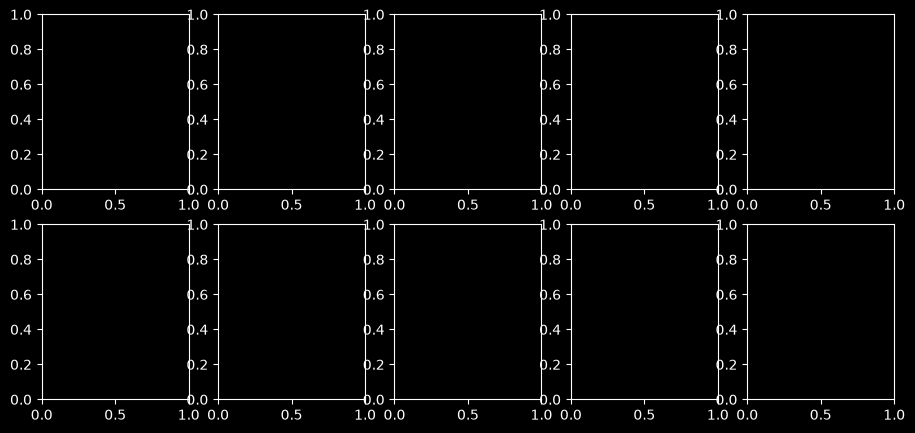

In [11]:
figure, axes = plt.subplots(
    2,
    5,
    figsize=(11, 5),
)

for position, axis in enumerate(axes.ravel()):
    image = X_test_subset[position]
    real_label = y_test[position]
    predicted_label = predictions[position]

    axis.imshow(
        image.T,
        cmap="gray",
    )

    axis.set_title(
        f"Real: {real_label} | Pred: {predicted_label}"
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

## 14. Analiza predicțiilor greșite

Predicțiile greșite sunt importante deoarece ne arată **unde și de ce modelul are dificultăți**.

Un model poate avea un accuracy bun și totuși să greșească anumite tipuri de cifre în mod repetat.

Prin inspectarea imaginilor greșite putem observa:

- cifre scrise neclar;
- cifre care seamănă vizual, precum `3` și `5`;
- cifre incomplete sau foarte înclinate;
- limitele modelului;
- situații în care analizarea separată a pixelilor nu este suficientă pentru a înțelege forma completă.

De exemplu:

`Real: 5 | Pred: 3`

înseamnă că imaginea reprezenta cifra `5`, dar modelul a considerat că tiparul pixelilor seamănă mai mult cu cifra `3`.

Pentru a găsi aceste exemple, comparăm fiecare predicție cu label-ul real.

Expresia:

`predictions != y_test`

produce câte o valoare pentru fiecare imagine:

- `False` dacă predicția este corectă;
- `True` dacă predicția este greșită.

Apoi folosim `np.where()` pentru a obține indicii imaginilor greșite.

Astfel putem afișa exact acele imagini și analiza dacă greșelile modelului sunt ușor de înțeles vizual.

In [ ]:
wrong_indices = np.where(
    predictions != y_test
)[0]

print(
    "Număr de predicții greșite:",
    len(wrong_indices),
)

print(
    "Primele poziții greșite:",
    wrong_indices[:10],
)

## Task 4 - Afișarea predicțiilor greșite

### Cerințe

1. Folosește primele 10 poziții din `wrong_indices`.
2. Afișează imaginile respective.
3. Afișează în titlu:
   - cifra reală;
   - cifra prezisă.
4. Observă dacă greșelile sunt ușor de înțeles vizual.

In [ ]:
figure, axes = plt.subplots(
    2,
    5,
    figsize=(11, 5),
)

for position, axis in enumerate(axes.ravel()):
    wrong_index = ...

    image = ...
    real_label = ...
    predicted_label = ...

    axis.imshow(
        ...,
        cmap="gray",
    )

    axis.set_title(
        ...
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

<details>
<summary><strong>Hint</strong></summary>

Poziția greșită este:

<pre><code>wrong_index = wrong_indices[position]</code></pre>

Apoi folosește același index în:

<pre><code>X_test_subset
y_test
predictions</code></pre>

Pentru afișare, imaginea trebuie transpusă cu `.T`.

</details>

<details>
<summary><strong>Soluție</strong></summary>

<pre><code>figure, axes = plt.subplots(
    2,
    5,
    figsize=(11, 5),
)

for position, axis in enumerate(
    axes.ravel()
):
    wrong_index = wrong_indices[
        position
    ]

    image = X_test_subset[
        wrong_index
    ]

    real_label = y_test[
        wrong_index
    ]

    predicted_label = predictions[
        wrong_index
    ]

    axis.imshow(
        image.T,
        cmap="gray",
    )

    axis.set_title(
        f"Real: {real_label} | Pred: {predicted_label}"
    )

    axis.axis("off")

plt.tight_layout()
plt.show()</code></pre>

</details>

# Task final - Construirea completă a modelului

În acest task vei reconstrui singur întregul pipeline de clasificare a imaginilor EMNIST-MNIST.

Vei porni de la dataset-ul descărcat și vei ajunge până la:

- pregătirea imaginilor;
- normalizarea pixelilor;
- antrenarea modelului;
- calcularea accuracy;
- afișarea matricei de confuzie;
- inspectarea predicțiilor;
- analiza imaginilor clasificate greșit.

Scopul este să legi toate etapele workshop-ului într-un singur flux complet.

## Cerințe

### 1. Pregătirea datelor

1. Extrage imaginile și label-urile din:
   - `train_dataset`;
   - `test_dataset`.
2. Transformă imaginile și label-urile în array-uri NumPy.
3. Selectează:
   - `15.000` imagini pentru train;
   - `3.000` imagini pentru test.
4. Folosește selecție stratificată pentru a păstra aproximativ aceeași proporție pentru fiecare cifră.
5. Folosește `random_state=42` pentru o selecție reproductibilă.

### 2. Pregătirea imaginilor pentru model

6. Păstrează imaginile selectate în forma `28 × 28` pentru afișare.
7. Creează separat o reprezentare aplatizată pentru model.
8. Transformă fiecare imagine într-un vector cu `784` de pixeli.
9. Verifică forma array-urilor rezultate pentru train și test.
10. Verifică dacă toate valorile pixelilor sunt nenegative.
11. Normalizează intensitățile pixelilor prin împărțirea la `255.0`.
12. Aplică aceeași normalizare atât datelor de train, cât și datelor de test.
13. Verifică dacă valorile normalizate sunt în intervalul `0–1`.

### 3. Construirea și antrenarea modelului

14. Creează modelul:

`MultinomialNB(alpha=1.0)`

15. Antrenează modelul folosind:
    - `X_train_normalized`;
    - `y_train`.
16. Obține predicțiile pentru `X_test_normalized`.

### 4. Evaluarea modelului

17. Calculează accuracy.
18. Afișează:
    - accuracy în format zecimal;
    - accuracy în procente.
19. Afișează raportul de clasificare pentru cifrele `0–9`.

### 5. Matricea de confuzie

20. Calculează matricea de confuzie.
21. Afișează matricea pentru cifrele `0–9`.
22. Folosește:
    - `ConfusionMatrixDisplay`;
    - `cmap="Blues"`;
    - `values_format="d"`.
23. Adaugă un titlu clar graficului.

### 6. Analiza confuziilor

24. Creează o copie a matricei de confuzie.
25. Pune valorile de pe diagonală pe `0`, astfel încât predicțiile corecte să fie ignorate.
26. Găsește cea mai mare valoare rămasă.
27. Afișează:
    - cifra reală;
    - cifra prezisă;
    - numărul de confuzii.

### 7. Vizualizarea predicțiilor

28. Afișează primele 10 imagini din test set.
29. Folosește imaginile originale, păstrate în forma `28 × 28`.
30. Pentru fiecare imagine, afișează în titlu:
    - label-ul real;
    - predicția modelului.

### 8. Analiza predicțiilor greșite

31. Găsește indicii pentru care:

`predictions != y_test`

32. Afișează numărul total de predicții greșite.
33. Afișează primele 10 imagini clasificate greșit.
34. Pentru fiecare imagine greșită, afișează:
    - cifra reală;
    - cifra prezisă.
35. Observă dacă cifrele confundate seamănă vizual sau sunt scrise neclar.

## Întrebări de interpretare

După rularea codului, răspunde la următoarele întrebări:

1. Ce accuracy a obținut modelul?
2. Care cifră a fost clasificată corect de cele mai multe ori?
3. Care a fost cea mai frecventă confuzie?
4. Cifra reală și cifra prezisă seamănă vizual?
5. Unele imagini greșite sunt ambigue chiar și pentru un om?
6. Ce limitare a lui Multinomial Naive Bayes poate explica aceste erori?

In [ ]:
# 1. Extragem imaginile și label-urile

X_train_images_all = ...
y_train_all = ...

X_test_images_all = ...
y_test_all = ...


# 2. Selectăm 15.000 de imagini pentru train
# și 3.000 de imagini pentru test

train_indices, _ = train_test_split(
    ...,
    train_size=...,
    random_state=...,
    stratify=...,
)

test_indices, _ = train_test_split(
    ...,
    train_size=...,
    random_state=...,
    stratify=...,
)

X_train_images = ...
y_train = ...

X_test_images = ...
y_test = ...


# 3. Aplatizăm imaginile în vectori cu 784 de pixeli

X_train = ...

X_test = ...

print(
    "Forma imaginilor train:",
    ...,
)

print(
    "Forma datelor train pentru model:",
    ...,
)

print(
    "Forma datelor test pentru model:",
    ...,
)

print(
    "Valoarea minimă înainte de normalizare:",
    ...,
)

print(
    "Valoarea maximă înainte de normalizare:",
    ...,
)


# 4. Normalizăm intensitățile pixelilor în intervalul 0-1

X_train_normalized = ...

X_test_normalized = ...

print(
    "Valoarea minimă după normalizare:",
    ...,
)

print(
    "Valoarea maximă după normalizare:",
    ...,
)


# 5. Construim și antrenăm modelul

model = ...

model.fit(
    ...,
    ...,
)

predictions = ...


# 6. Calculăm și afișăm accuracy

accuracy = ...

print(
    "Accuracy:",
    ...,
)

print(
    "Accuracy în procente:",
    ...,
)


# 7. Afișăm raportul de clasificare

print("\nRaport de clasificare:")

print(
    classification_report(
        ...,
        ...,
    )
)


# 8. Construim și afișăm matricea de confuzie

confusion = ...

display_confusion = ConfusionMatrixDisplay(
    confusion_matrix=...,
    display_labels=...,
)

display_confusion.plot(
    cmap=...,
    values_format=...,
)

plt.title(...)
plt.show()


# 9. Găsim cea mai frecventă confuzie

confusion_without_diagonal = ...

np.fill_diagonal(
    ...,
    0,
)

most_confused_position = np.unravel_index(
    np.argmax(...),
    ...,
)

real_digit = ...
predicted_digit = ...

confusion_count = ...

print(
    "Cifra reală:",
    ...,
)

print(
    "Cifra prezisă:",
    ...,
)

print(
    "Număr de confuzii:",
    ...,
)


# 10. Afișăm primele 10 predicții

figure, axes = plt.subplots(
    2,
    5,
    figsize=(11, 5),
)

for position, axis in enumerate(
    axes.ravel()
):
    image = ...
    real_label = ...
    predicted_label = ...

    axis.imshow(
        ...,
        cmap="gray",
    )

    axis.set_title(
        ...
    )

    axis.axis("off")

plt.tight_layout()
plt.show()


# 11. Găsim predicțiile greșite

wrong_indices = ...

print(
    "Număr de predicții greșite:",
    ...,
)


# 12. Afișăm primele 10 predicții greșite

figure, axes = plt.subplots(
    2,
    5,
    figsize=(11, 5),
)

for position, axis in enumerate(
    axes.ravel()
):
    wrong_index = ...

    image = ...
    real_label = ...
    predicted_label = ...

    axis.imshow(
        ...,
        cmap="gray",
    )

    axis.set_title(
        ...
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

<details>
<summary><strong>Hint</strong></summary>

Extrage imaginile și label-urile din obiectele `EMNIST`:

<pre><code>X_train_images_all = train_dataset.data.numpy()
y_train_all = train_dataset.targets.numpy()

X_test_images_all = test_dataset.data.numpy()
y_test_all = test_dataset.targets.numpy()</code></pre>

Pentru selecția subseturilor, construiește mai întâi toți indicii disponibili:

<pre><code>np.arange(len(X_train_images_all))</code></pre>

Folosește apoi:

<pre><code>train_test_split(
    indicii,
    train_size=15_000,
    random_state=42,
    stratify=y_train_all,
)</code></pre>

Pentru test set procedezi la fel, dar cu:

<pre><code>train_size=3_000</code></pre>

Selectează imaginile și label-urile folosind indicii obținuți:

<pre><code>X_train_images = X_train_images_all[
    train_indices
]

y_train = y_train_all[
    train_indices
]</code></pre>

Aplatizează fiecare imagine `28 × 28` într-un vector cu `784` de pixeli:

<pre><code>X_train = X_train_images.reshape(
    len(X_train_images),
    28 * 28,
)

X_test = X_test_images.reshape(
    len(X_test_images),
    28 * 28,
)</code></pre>

Normalizează intensitățile pixelilor prin împărțirea la `255.0`:

<pre><code>X_train_normalized = (
    X_train.astype("float32") / 255.0
)

X_test_normalized = (
    X_test.astype("float32") / 255.0
)</code></pre>

După normalizare, valorile ar trebui să fie în intervalul `0–1`:

<pre><code>X_train_normalized.min()
X_train_normalized.max()</code></pre>

Construiește modelul astfel:

<pre><code>model = MultinomialNB(
    alpha=1.0
)</code></pre>

Antrenează modelul folosind datele normalizate:

<pre><code>model.fit(
    X_train_normalized,
    y_train,
)</code></pre>

Predicțiile se obțin tot din datele normalizate:

<pre><code>predictions = model.predict(
    X_test_normalized
)</code></pre>

Accuracy se calculează cu:

<pre><code>accuracy_score(
    y_test,
    predictions,
)</code></pre>

Matricea de confuzie:

<pre><code>confusion = confusion_matrix(
    y_test,
    predictions,
)</code></pre>

Pentru a ignora predicțiile corecte atunci când cauți cea mai frecventă confuzie:

<pre><code>confusion_without_diagonal = confusion.copy()

np.fill_diagonal(
    confusion_without_diagonal,
    0,
)</code></pre>

Poziția celei mai mari valori se găsește cu:

<pre><code>most_confused_position = np.unravel_index(
    np.argmax(confusion_without_diagonal),
    confusion_without_diagonal.shape,
)</code></pre>

Indicii predicțiilor greșite:

<pre><code>wrong_indices = np.where(
    predictions != y_test
)[0]</code></pre>

Când afișezi imaginile, folosește imaginile originale `28 × 28`, nu vectorii normalizați.

Pentru orientarea corectă folosește `.T`:

<pre><code>axis.imshow(
    image.T,
    cmap="gray",
)</code></pre>

</details>

<details>
<summary><strong>Soluție</strong></summary>

<pre><code># 1. Extragem imaginile și label-urile

X_train_images_all = (
    train_dataset.data.numpy()
)

y_train_all = (
    train_dataset.targets.numpy()
)

X_test_images_all = (
    test_dataset.data.numpy()
)

y_test_all = (
    test_dataset.targets.numpy()
)


# 2. Selectăm 15.000 de imagini pentru train
# și 3.000 de imagini pentru test

train_indices, _ = train_test_split(
    np.arange(
        len(X_train_images_all)
    ),
    train_size=15_000,
    random_state=42,
    stratify=y_train_all,
)

test_indices, _ = train_test_split(
    np.arange(
        len(X_test_images_all)
    ),
    train_size=3_000,
    random_state=42,
    stratify=y_test_all,
)

X_train_images = X_train_images_all[
    train_indices
]

y_train = y_train_all[
    train_indices
]

X_test_images = X_test_images_all[
    test_indices
]

y_test = y_test_all[
    test_indices
]


# 3. Aplatizăm imaginile în vectori cu 784 de pixeli

X_train = X_train_images.reshape(
    len(X_train_images),
    28 * 28,
)

X_test = X_test_images.reshape(
    len(X_test_images),
    28 * 28,
)

print(
    "Forma imaginilor train:",
    X_train_images.shape,
)

print(
    "Forma datelor train pentru model:",
    X_train.shape,
)

print(
    "Forma datelor test pentru model:",
    X_test.shape,
)

print(
    "Valoarea minimă înainte de normalizare:",
    X_train.min(),
)

print(
    "Valoarea maximă înainte de normalizare:",
    X_train.max(),
)


# 4. Normalizăm intensitățile pixelilor în intervalul 0-1

X_train_normalized = (
    X_train.astype("float32") / 255.0
)

X_test_normalized = (
    X_test.astype("float32") / 255.0
)

print(
    "Valoarea minimă după normalizare:",
    X_train_normalized.min(),
)

print(
    "Valoarea maximă după normalizare:",
    X_train_normalized.max(),
)


# 5. Construim și antrenăm modelul

model = MultinomialNB(
    alpha=1.0
)

model.fit(
    X_train_normalized,
    y_train,
)

predictions = model.predict(
    X_test_normalized
)


# 6. Calculăm și afișăm accuracy

accuracy = accuracy_score(
    y_test,
    predictions,
)

print(
    "Accuracy:",
    accuracy,
)

print(
    "Accuracy în procente:",
    accuracy * 100,
)


# 7. Afișăm raportul de clasificare

print("\nRaport de clasificare:")

print(
    classification_report(
        y_test,
        predictions,
    )
)


# 8. Construim și afișăm matricea de confuzie

confusion = confusion_matrix(
    y_test,
    predictions,
)

display_confusion = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=np.arange(10),
)

display_confusion.plot(
    cmap="Blues",
    values_format="d",
)

plt.title(
    "Matricea de confuzie — EMNIST-MNIST"
)

plt.show()


# 9. Găsim cea mai frecventă confuzie

confusion_without_diagonal = (
    confusion.copy()
)

np.fill_diagonal(
    confusion_without_diagonal,
    0,
)

most_confused_position = np.unravel_index(
    np.argmax(
        confusion_without_diagonal
    ),
    confusion_without_diagonal.shape,
)

real_digit = most_confused_position[0]
predicted_digit = most_confused_position[1]

confusion_count = (
    confusion_without_diagonal[
        real_digit,
        predicted_digit,
    ]
)

print(
    "Cifra reală:",
    real_digit,
)

print(
    "Cifra prezisă:",
    predicted_digit,
)

print(
    "Număr de confuzii:",
    confusion_count,
)


# 10. Afișăm primele 10 predicții

figure, axes = plt.subplots(
    2,
    5,
    figsize=(11, 5),
)

for position, axis in enumerate(
    axes.ravel()
):
    image = X_test_images[
        position
    ]

    real_label = y_test[
        position
    ]

    predicted_label = predictions[
        position
    ]

    axis.imshow(
        image.T,
        cmap="gray",
    )

    axis.set_title(
        f"Real: {real_label} | Pred: {predicted_label}"
    )

    axis.axis("off")

plt.tight_layout()
plt.show()


# 11. Găsim predicțiile greșite

wrong_indices = np.where(
    predictions != y_test
)[0]

print(
    "Număr de predicții greșite:",
    len(wrong_indices),
)


# 12. Afișăm primele 10 predicții greșite

figure, axes = plt.subplots(
    2,
    5,
    figsize=(11, 5),
)

for position, axis in enumerate(
    axes.ravel()
):
    wrong_index = wrong_indices[
        position
    ]

    image = X_test_images[
        wrong_index
    ]

    real_label = y_test[
        wrong_index
    ]

    predicted_label = predictions[
        wrong_index
    ]

    axis.imshow(
        image.T,
        cmap="gray",
    )

    axis.set_title(
        f"Real: {real_label} | Pred: {predicted_label}"
    )

    axis.axis("off")

plt.tight_layout()
plt.show()</code></pre>

</details>